# Assignment-1 - Vanilla Autoencoder: MNIST, Fashion-MNIST & Combined

| | |
|---|---|
| **Course:** | PROG74040 - Advanced Topics in Artificial Intelligence and Machine Learning |
| **Group Number:** | Group 5 |
| **Team members:** | Ansh, Henil, Kahan |

---

| Step | Description |
|------|-------------|
| 1 | Common setup: imports, configuration, data loading (shared across notebooks) |
| 2 | Dataset exploration and analysis (this notebook only) |
| 3 | Autoencoder model definition and helper functions |
| 4 | Train on MNIST, visualize latent space, generate images |
| 5 | Train on Fashion-MNIST, visualize latent space, generate images |
| 6 | Train on Combined dataset, visualize latent space, generate images |
| 7 | Reconstruction comparison and model saving |

---
## Section 1: Common Setup

The cells in this section are shared across all three notebooks (Vanilla AE, VAE, GAN).
They cover imports, training configuration, dataset loading, normalization, and combined-dataset construction.

### Imports

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, TensorDataset

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
import os

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


### Training Configuration

All tunable training parameters are defined here. Adjust these values to control model behavior without touching the rest of the notebook.

| Parameter | Default | Effect |
|-----------|---------|--------|
| `BATCH_SIZE` | 128 | Mini-batch size; larger = faster but more memory |
| `EPOCHS` | 20 | Training passes over the full dataset; more = lower loss |
| `LEARNING_RATE` | 1e-3 | Adam step size; try 1e-4 for slower, finer convergence |
| `LATENT_DIM` | 2 | Bottleneck size; keep 2 for scatter plots, raise to 8/16/32 for reconstruction quality |
| `GRID_SIZE` | 15 | Resolution of the generated latent-space image grid |

In [6]:
BATCH_SIZE    = 128
EPOCHS        = 20
LEARNING_RATE = 1e-3
LATENT_DIM    = 2      # 2 enables 2D scatter plot visualization
GRID_SIZE     = 15     # grid dimension for the generated image canvas

print(f'Batch size    : {BATCH_SIZE}')
print(f'Epochs        : {EPOCHS}')
print(f'Learning rate : {LEARNING_RATE}')
print(f'Latent dim    : {LATENT_DIM}')
print(f'Grid size     : {GRID_SIZE}')

Batch size    : 128
Epochs        : 20
Learning rate : 0.001
Latent dim    : 2
Grid size     : 15


### Data Loading and Preprocessing

`transforms.ToTensor()` converts PIL images to PyTorch tensors and scales pixel values from `[0, 255]` to `[0, 1]`.

The combined dataset is built by concatenating MNIST and Fashion-MNIST training splits.
Since both datasets use integer labels 0-9, an offset loader is constructed for the combined test set
that shifts Fashion-MNIST labels to 10-19, making all 20 classes distinguishable in scatter plots.

In [7]:
transform = transforms.ToTensor()

# MNIST
mnist_train = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
mnist_test  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Fashion-MNIST
fmnist_train = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
fmnist_test  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Combined dataset: both label sets stay 0-9; offset is applied at visualization time
combined_train = ConcatDataset([mnist_train, fmnist_train])
combined_test  = ConcatDataset([mnist_test,  fmnist_test])

# Training loaders
mnist_loader    = DataLoader(mnist_train,    batch_size=BATCH_SIZE, shuffle=True)
fmnist_loader   = DataLoader(fmnist_train,   batch_size=BATCH_SIZE, shuffle=True)
combined_loader = DataLoader(combined_train, batch_size=BATCH_SIZE, shuffle=True)

# Test loaders
mnist_test_loader    = DataLoader(mnist_test,    batch_size=256, shuffle=False)
fmnist_test_loader   = DataLoader(fmnist_test,   batch_size=256, shuffle=False)
combined_test_loader = DataLoader(combined_test, batch_size=256, shuffle=False)

# Class name lookups
mnist_classes  = [str(i) for i in range(10)]
fmnist_classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                  'Sandal',  'Shirt',   'Sneaker',  'Bag',   'Ankle boot']

# Combined offset loader: Fashion-MNIST labels shifted to 10-19
def make_offset_combined_test():
    all_images, all_labels = [], []
    for imgs, lbls in mnist_test_loader:
        all_images.append(imgs)
        all_labels.append(lbls)
    for imgs, lbls in fmnist_test_loader:
        all_images.append(imgs)
        all_labels.append(lbls + 10)
    return DataLoader(
        TensorDataset(torch.cat(all_images), torch.cat(all_labels)),
        batch_size=256, shuffle=False
    )

combined_offset_loader = make_offset_combined_test()
combined_class_names   = [f'D:{c}' for c in mnist_classes] + [f'F:{c}' for c in fmnist_classes]

print(f'MNIST         - train: {len(mnist_train):,}  |  test: {len(mnist_test):,}')
print(f'Fashion-MNIST - train: {len(fmnist_train):,}  |  test: {len(fmnist_test):,}')
print(f'Combined      - train: {len(combined_train):,}  |  test: {len(combined_test):,}')

MNIST         - train: 60,000  |  test: 10,000
Fashion-MNIST - train: 60,000  |  test: 10,000
Combined      - train: 120,000  |  test: 20,000


---
## Section 2: Dataset Exploration

This section is specific to this notebook. We visualize the datasets and analyze their differences
before training begins.

### Sample Images

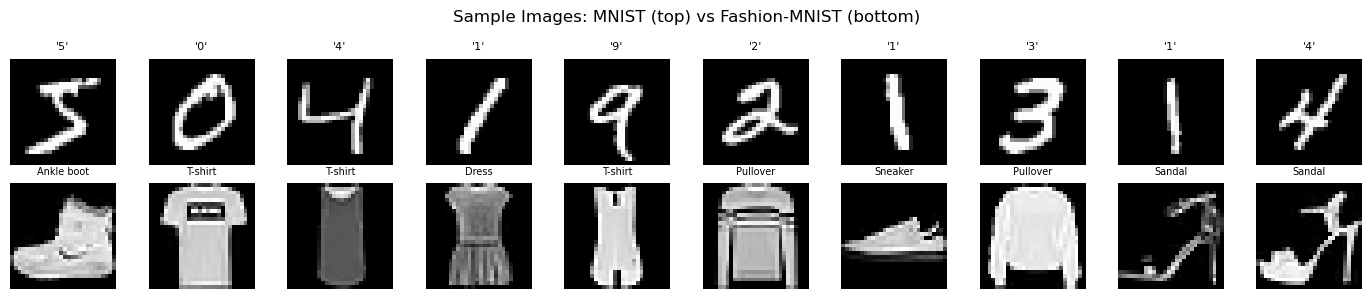

In [8]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
fig.suptitle('Sample Images: MNIST (top) vs Fashion-MNIST (bottom)', fontsize=12)

for i in range(10):
    img, label = mnist_train[i]
    axes[0, i].imshow(img.squeeze(), cmap='gray')
    axes[0, i].set_title(f"'{mnist_classes[label]}'", fontsize=8)
    axes[0, i].axis('off')

    img, label = fmnist_train[i]
    axes[1, i].imshow(img.squeeze(), cmap='gray')
    axes[1, i].set_title(fmnist_classes[label], fontsize=7)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('MNIST',   fontsize=9)
axes[1, 0].set_ylabel('Fashion', fontsize=9)
plt.tight_layout()
plt.show()

### Class Distributions

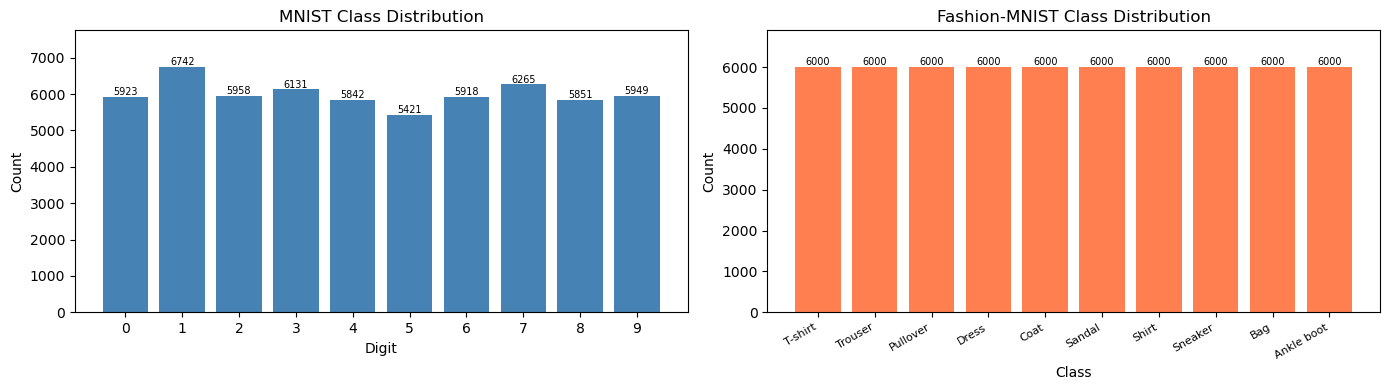

MNIST         - min class: 5,421  max class: 6,742
Fashion-MNIST - min class: 6,000  max class: 6,000


In [9]:
mnist_labels  = mnist_train.targets.numpy()
fmnist_labels = fmnist_train.targets.numpy()

mnist_counts  = [(mnist_labels  == i).sum() for i in range(10)]
fmnist_counts = [(fmnist_labels == i).sum() for i in range(10)]

x = range(10)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(x, mnist_counts, color='steelblue')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(mnist_classes)
axes[0].set_title('MNIST Class Distribution')
axes[0].set_xlabel('Digit')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(mnist_counts) * 1.15)
for i, v in enumerate(mnist_counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=7)

axes[1].bar(x, fmnist_counts, color='coral')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(fmnist_classes, rotation=30, ha='right', fontsize=8)
axes[1].set_title('Fashion-MNIST Class Distribution')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(fmnist_counts) * 1.15)
for i, v in enumerate(fmnist_counts):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=7)

plt.tight_layout()
plt.show()

print(f'MNIST         - min class: {min(mnist_counts):,}  max class: {max(mnist_counts):,}')
print(f'Fashion-MNIST - min class: {min(fmnist_counts):,}  max class: {max(fmnist_counts):,}')

### Observations and Analysis

**Dataset Comparison**

| Property | MNIST | Fashion-MNIST |
|----------|-------|---------------|
| Content | Handwritten digits (0-9) | Clothing items (10 categories) |
| Visual complexity | Low: thin strokes on near-uniform background | Higher: textures, edges, shading |
| Intra-class variance | Moderate: different handwriting styles | High: same item varies by style and orientation |
| Class separability | High: digits are largely distinct shapes | Lower: e.g. Shirt vs T-shirt, Coat vs Pullover |
| Background | Near-uniform black | Slightly more variable |
| Class balance | Approximately uniform (~6,000 per class) | Approximately uniform (~6,000 per class) |

**Key Differences**

- **Visual complexity:** MNIST digits are defined by simple contour strokes. Fashion-MNIST images contain surface textures (fabric grain, soles, buckles) requiring more representational capacity from the encoder.
- **Intra-class variation:** A digit "7" is recognizable regardless of handwriting style. A "Shirt" however can appear as a polo, button-up, or v-neck within the same class label, making the encoder's job harder.
- **Class separability:** MNIST classes are visually well-separated. Fashion-MNIST has visually similar class pairs (Coat/Pullover, Shirt/T-shirt) that are harder to separate in a low-dimensional latent space.

**Potential Challenges When Combining**

1. **Label collision:** Both datasets use integer labels 0-9, making the integer label alone ambiguous (e.g. label `3` could be the digit "3" or a "Dress"). The offset loader adds 10 to Fashion-MNIST labels to resolve this for visualization.
2. **Representational competition:** With a 2D latent space, the encoder must represent 20 visually distinct categories simultaneously. The bottleneck is more constrained than when training on a single 10-class dataset, and cluster separation will likely degrade.
3. **Domain gap:** Digit contours and clothing textures are fundamentally different image types. The model must find a shared latent geometry for two distinct visual domains, which can push unrelated classes into adjacent latent regions and reduce the interpretability of the space.
4. **Unequal complexity:** MNIST samples are typically lower entropy (sparser, simpler patterns). The optimizer may converge toward representations that prioritize digits, potentially producing slightly blurrier clothing reconstructions as a result.

---
## Vanilla Autoencoder Model

### Architecture

```
Input image (28x28 = 784 pixels)
        |
   [ Encoder ]  784 -> 256 -> 128 -> LATENT_DIM
        |
   latent vector z  (2 numbers per image by default)
        |
   [ Decoder ]  LATENT_DIM -> 128 -> 256 -> 784
        |
 Reconstructed image (784 -> reshape to 28x28)
```

- **ReLU** activations between hidden layers introduce non-linearity.
- **Sigmoid** at the output squashes values to `[0, 1]` to match normalized pixel range.
- **MSE loss** measures pixel-level reconstruction error.

In [10]:
class VanillaAutoencoder(nn.Module):
    """
    MLP Autoencoder for 28x28 grayscale images.

    Encoder: 784 -> 256 -> 128 -> latent_dim
    Decoder: latent_dim -> 128 -> 256 -> 784
    """

    def __init__(self, latent_dim=2):
        super(VanillaAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 784)
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        reconstructed = reconstructed.view(-1, 1, 28, 28)
        return reconstructed, z

    def encode(self, x):
        return self.encoder(x.view(-1, 784))

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)


# Sanity check
dummy  = torch.zeros(8, 1, 28, 28)
m      = VanillaAutoencoder(latent_dim=LATENT_DIM)
r, z   = m(dummy)
print(f'Input  shape: {dummy.shape}')
print(f'Latent shape: {z.shape}   <- {LATENT_DIM} numbers per image')
print(f'Output shape: {r.shape}')
print(m)

Input  shape: torch.Size([8, 1, 28, 28])
Latent shape: torch.Size([8, 2])   <- 2 numbers per image
Output shape: torch.Size([8, 1, 28, 28])
VanillaAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


### Helper Functions

Defined once and reused across all three training runs.

In [11]:
# HELPER 1: Training loop
def train_autoencoder(model, dataloader, epochs, lr, device):
    model.to(device)
    model.train()

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses    = []

    for epoch in range(1, epochs + 1):
        running_loss = 0.0

        for batch_images, _ in dataloader:
            batch_images = batch_images.to(device)
            reconstructed, _ = model(batch_images)
            loss = criterion(reconstructed, batch_images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(dataloader)
        losses.append(avg_loss)

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:>2}/{epochs}  |  Loss: {avg_loss:.5f}')

    return losses


# HELPER 2: Training loss curve
def plot_loss(losses, title):
    plt.figure(figsize=(6, 3))
    plt.plot(losses, color='steelblue', linewidth=2)
    plt.title(f'Training Loss: {title}')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# HELPER 3: Latent space scatter plot
def plot_latent_space(model, test_loader, class_names, title, device, max_samples=5000):
    model.eval()
    model.to(device)

    all_z, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            all_z.append(model.encode(images.to(device)).cpu().numpy())
            all_labels.append(labels.numpy())
            if sum(len(l) for l in all_labels) >= max_samples:
                break

    all_z      = np.concatenate(all_z,      axis=0)[:max_samples]
    all_labels = np.concatenate(all_labels, axis=0)[:max_samples]

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(all_z[:, 0], all_z[:, 1],
                         c=all_labels, cmap='tab20', s=6, alpha=0.6)

    cbar = plt.colorbar(scatter, ax=ax, ticks=range(len(class_names)))
    cbar.ax.set_yticklabels(class_names)

    ax.set_title(f'Latent Space (2D): {title}', fontsize=13)
    ax.set_xlabel('Latent Dimension 1')
    ax.set_ylabel('Latent Dimension 2')
    plt.tight_layout()
    plt.show()


# HELPER 4: Generated image grid
# Collects n_per_class test images per class, encodes then decodes each,
# and displays them in a grid with one row per class.
def generate_image_grid(model, test_loader, class_names, title, device, n_per_class=5):
    model.eval()
    model.to(device)

    n_classes    = len(class_names)
    class_images = {i: [] for i in range(n_classes)}

    for images, labels in test_loader:
        for img, lbl in zip(images, labels):
            c = lbl.item()
            if c in class_images and len(class_images[c]) < n_per_class:
                class_images[c].append(img)
        if all(len(v) >= n_per_class for v in class_images.values()):
            break

    fig, axes = plt.subplots(n_classes, n_per_class,
                             figsize=(n_per_class * 1.5, n_classes * 1.5))
    fig.suptitle(f'Generated Images by Class: {title}', fontsize=12, y=1.01)

    with torch.no_grad():
        for ci in range(n_classes):
            for si in range(n_per_class):
                img_t   = class_images[ci][si].unsqueeze(0).to(device)
                decoded = model.decode(model.encode(img_t)).squeeze().cpu().numpy()
                ax      = axes[ci, si] if n_classes > 1 else axes[si]
                ax.imshow(decoded, cmap='gray')
                ax.axis('off')
            row_ax = axes[ci, 0] if n_classes > 1 else axes[0]
            row_ax.set_ylabel(class_names[ci], fontsize=6, rotation=0,
                              labelpad=38, va='center')

    plt.tight_layout()
    plt.show()
    print(f'{n_per_class} decoded samples per class across {n_classes} classes')


print('Helper functions defined.')

Helper functions defined.


---
## Load Saved Models (Skip Retraining)

If models have already been trained and saved, run the cell below instead of the three training cells.
This restores all three model objects into memory so every visualization cell works without retraining.

In [12]:
model_mnist    = VanillaAutoencoder(latent_dim=LATENT_DIM)
model_fmnist   = VanillaAutoencoder(latent_dim=LATENT_DIM)
model_combined = VanillaAutoencoder(latent_dim=LATENT_DIM)

model_mnist.load_state_dict(   torch.load('saved_models/autoencoder_mnist.pth',    map_location=device))
model_fmnist.load_state_dict(  torch.load('saved_models/autoencoder_fmnist.pth',   map_location=device))
model_combined.load_state_dict(torch.load('saved_models/autoencoder_combined.pth', map_location=device))

model_mnist.eval()
model_fmnist.eval()
model_combined.eval()

print('Models loaded from saved_models/')
print('  autoencoder_mnist.pth')
print('  autoencoder_fmnist.pth')
print('  autoencoder_combined.pth')

Models loaded from saved_models/
  autoencoder_mnist.pth
  autoencoder_fmnist.pth
  autoencoder_combined.pth


---
## Training: MNIST

A fresh autoencoder trained exclusively on handwritten digit images.

  Training on MNIST
  Epoch  1/20  |  Loss: 0.05956
  Epoch  5/20  |  Loss: 0.04138
  Epoch 10/20  |  Loss: 0.03874
  Epoch 15/20  |  Loss: 0.03725
  Epoch 20/20  |  Loss: 0.03638


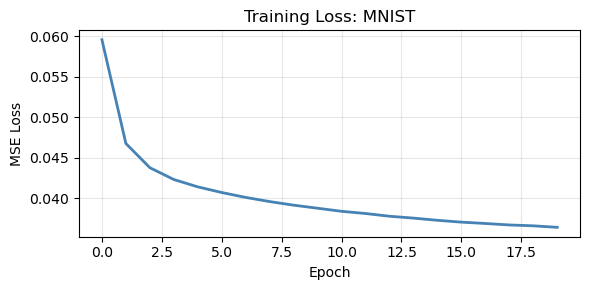

In [ ]:
print('=' * 55)
print('  Training on MNIST')
print('=' * 55)

model_mnist  = VanillaAutoencoder(latent_dim=LATENT_DIM)
losses_mnist = train_autoencoder(
    model=model_mnist,
    dataloader=mnist_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device
)

plot_loss(losses_mnist, title='MNIST')

### Latent Space (MNIST)

Each test image is encoded to a 2D point. Well-separated clusters indicate the model has learned
to group similar digits together despite the tight bottleneck.

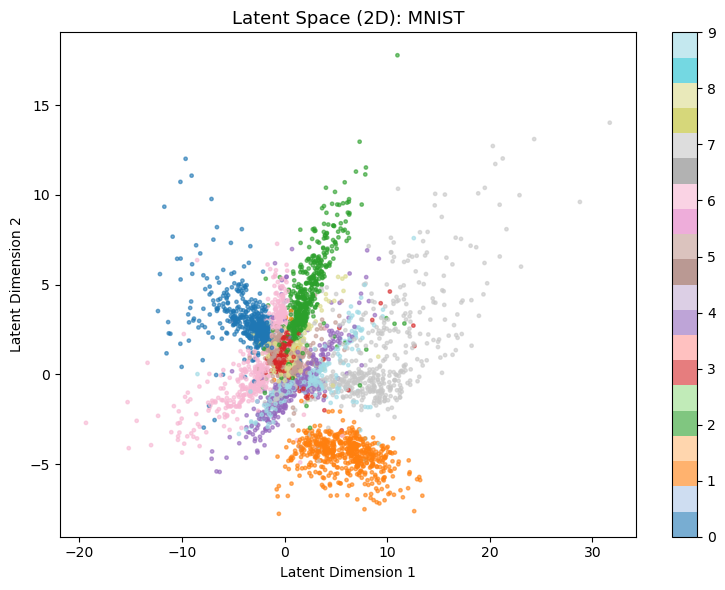

In [ ]:
plot_latent_space(
    model=model_mnist,
    test_loader=mnist_test_loader,
    class_names=mnist_classes,
    title='MNIST',
    device=device
)

### Generated Images (MNIST)

Latent points sampled on a regular grid are decoded into images, showing how the decoder
interpolates across the learned latent space.

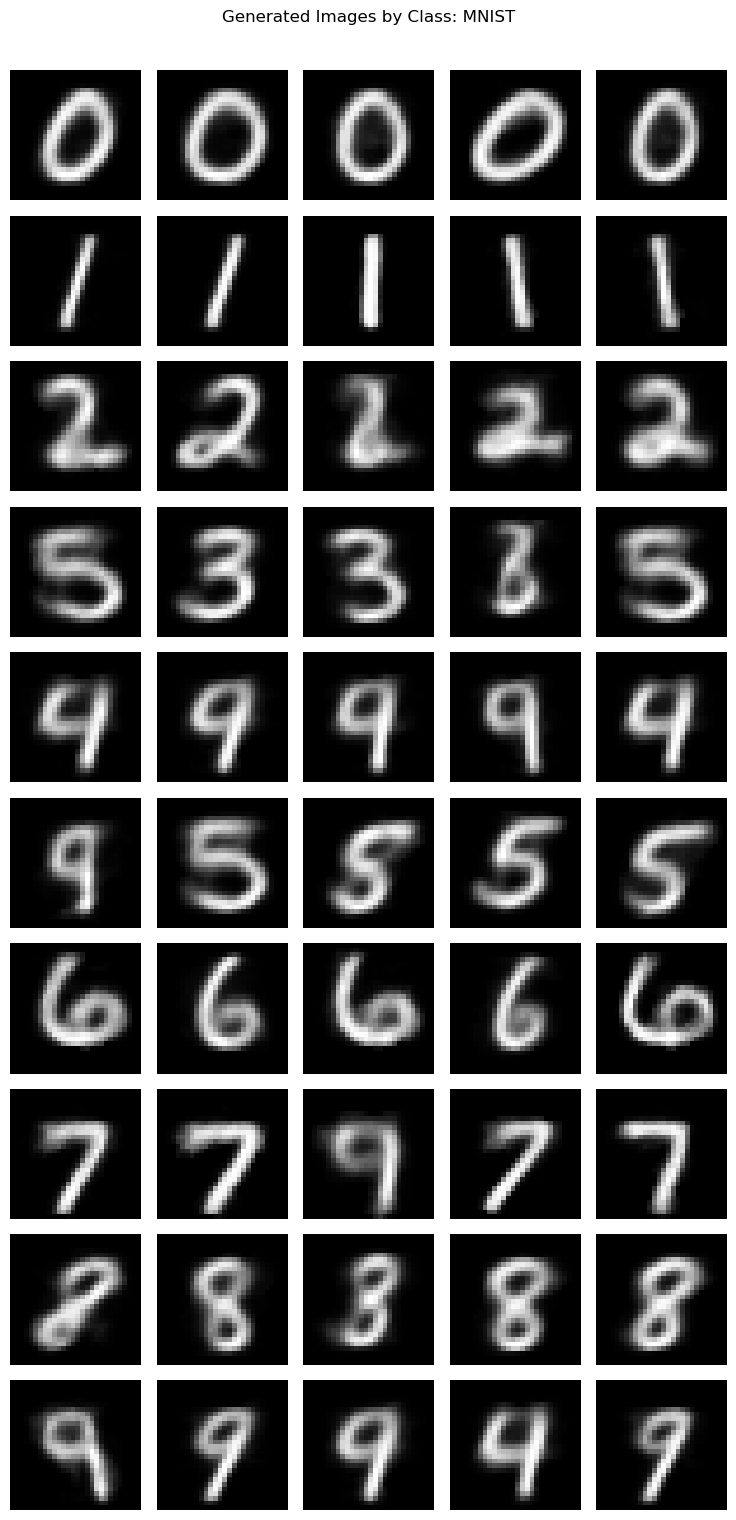

5 decoded samples per class across 10 classes


In [13]:
generate_image_grid(model_mnist, mnist_test_loader, mnist_classes, 'MNIST', device)

---
## Training: Fashion-MNIST

A fresh autoencoder trained exclusively on clothing item images.

  Training on Fashion-MNIST
  Epoch  1/20  |  Loss: 0.04368
  Epoch  5/20  |  Loss: 0.02784
  Epoch 10/20  |  Loss: 0.02647
  Epoch 15/20  |  Loss: 0.02558
  Epoch 20/20  |  Loss: 0.02497


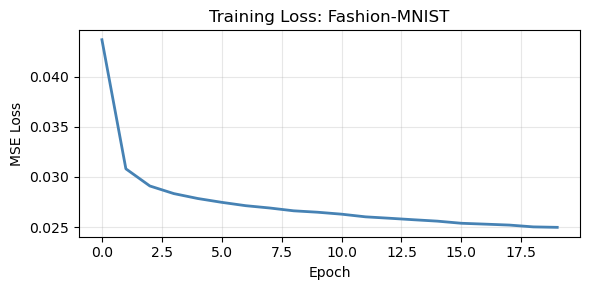

In [ ]:
print('=' * 55)
print('  Training on Fashion-MNIST')
print('=' * 55)

model_fmnist  = VanillaAutoencoder(latent_dim=LATENT_DIM)
losses_fmnist = train_autoencoder(
    model=model_fmnist,
    dataloader=fmnist_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device
)

plot_loss(losses_fmnist, title='Fashion-MNIST')

### Latent Space (Fashion-MNIST)

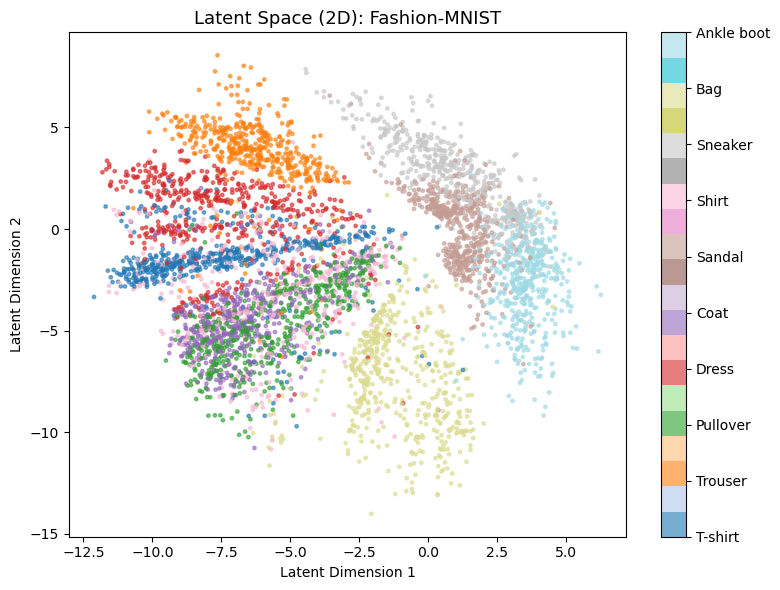

In [ ]:
plot_latent_space(
    model=model_fmnist,
    test_loader=fmnist_test_loader,
    class_names=fmnist_classes,
    title='Fashion-MNIST',
    device=device
)

### Generated Images (Fashion-MNIST)

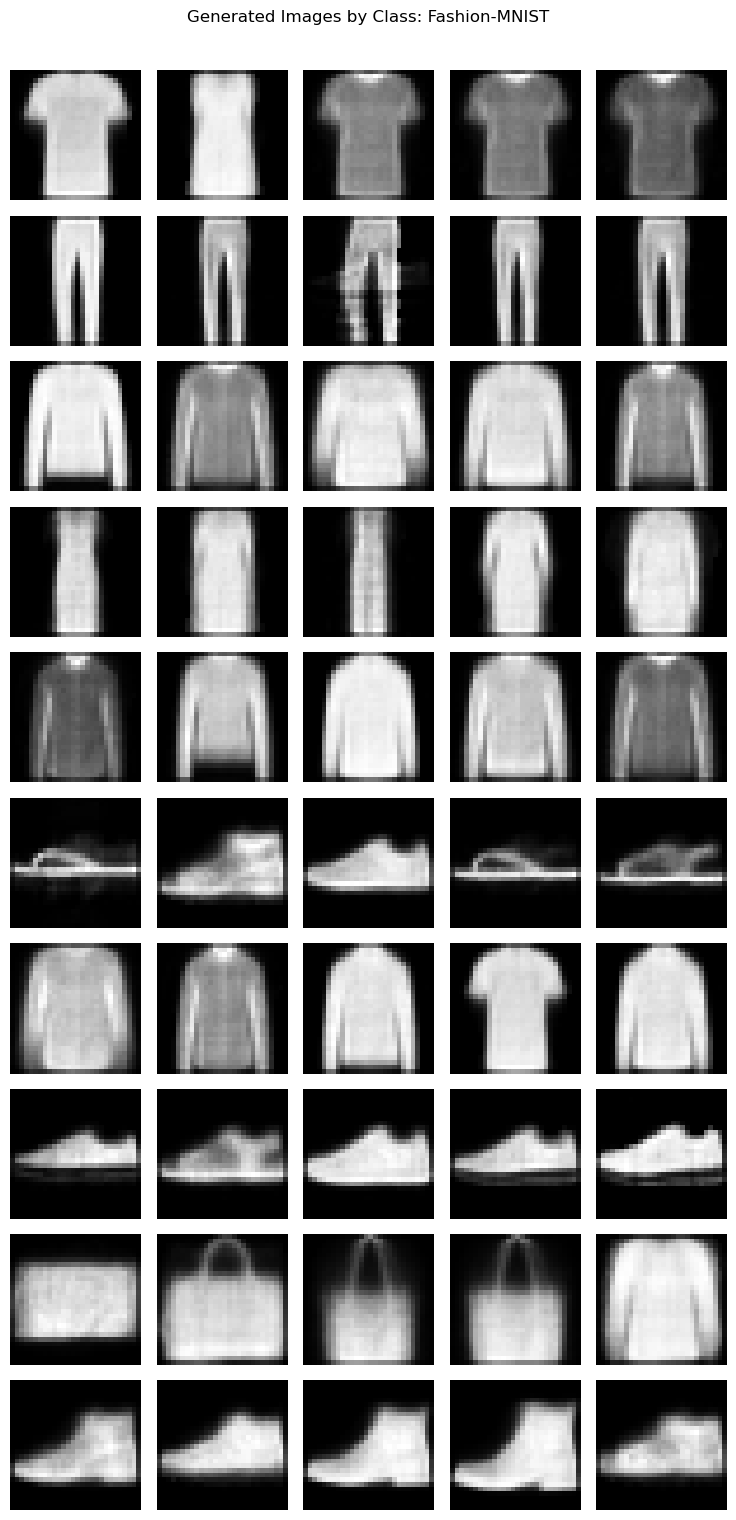

5 decoded samples per class across 10 classes


In [14]:
generate_image_grid(model_fmnist, fmnist_test_loader, fmnist_classes, 'Fashion-MNIST', device)

---
## Training: Combined Dataset

A fresh autoencoder trained on both MNIST and Fashion-MNIST (120,000 training images).
The latent space must now accommodate two visually distinct image domains simultaneously.

  Training on Combined (MNIST + Fashion-MNIST)
  Epoch  1/20  |  Loss: 0.04960
  Epoch  5/20  |  Loss: 0.03566
  Epoch 10/20  |  Loss: 0.03306
  Epoch 15/20  |  Loss: 0.03199
  Epoch 20/20  |  Loss: 0.03127


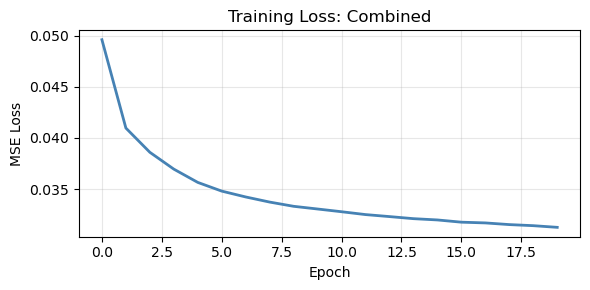

In [ ]:
print('=' * 55)
print('  Training on Combined (MNIST + Fashion-MNIST)')
print('=' * 55)

model_combined  = VanillaAutoencoder(latent_dim=LATENT_DIM)
losses_combined = train_autoencoder(
    model=model_combined,
    dataloader=combined_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device
)

plot_loss(losses_combined, title='Combined')

### Latent Space (Combined)

The offset test loader assigns MNIST classes to labels 0-9 (prefix `D:`) and
Fashion-MNIST classes to labels 10-19 (prefix `F:`), making all 20 classes visually distinct.

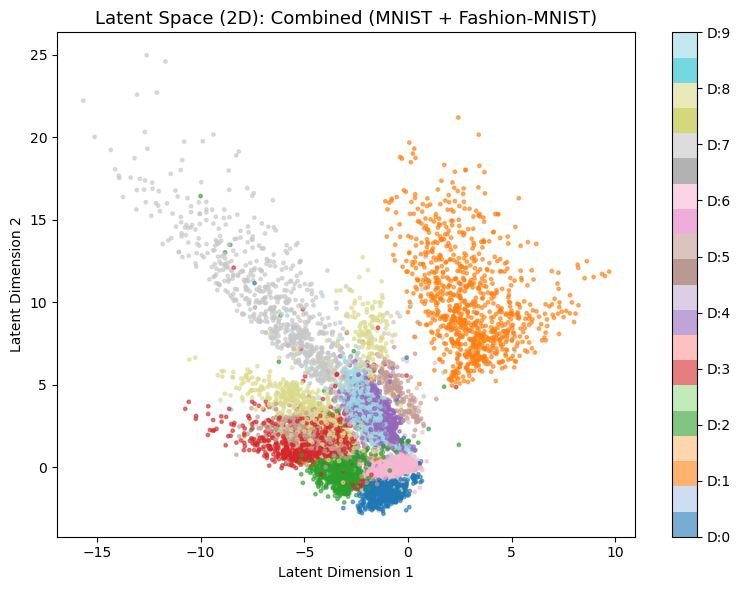

In [ ]:
plot_latent_space(
    model=model_combined,
    test_loader=combined_offset_loader,
    class_names=combined_class_names,
    title='Combined (MNIST + Fashion-MNIST)',
    device=device,
    max_samples=8000
)

### Generated Images (Combined)

In [ ]:
# Use the offset loader so all 20 classes have unique labels (0-9 for MNIST, 10-19 for Fashion-MNIST)
generate_image_grid(model_combined, combined_offset_loader, combined_class_names,
                    'Combined', device, n_per_class=3)

---
## Reconstruction Quality Check

Original test images (top row) compared against their reconstructions (bottom row).
This gives a direct visual measure of how much detail survives the 2D bottleneck.

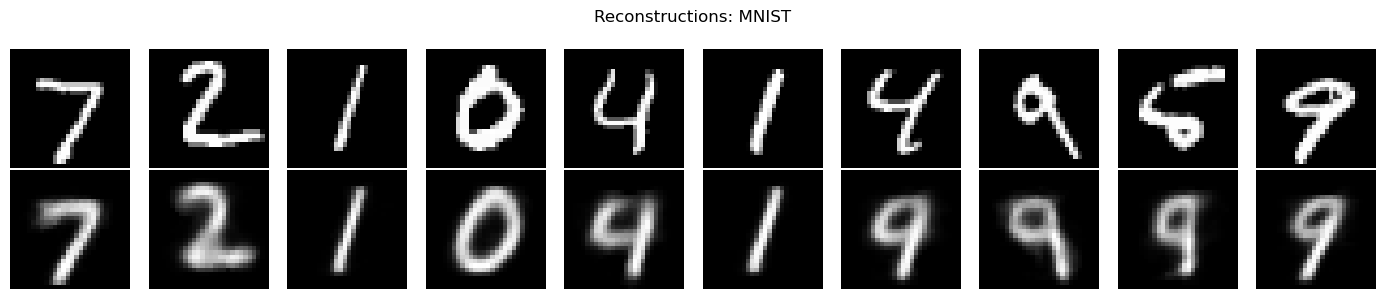

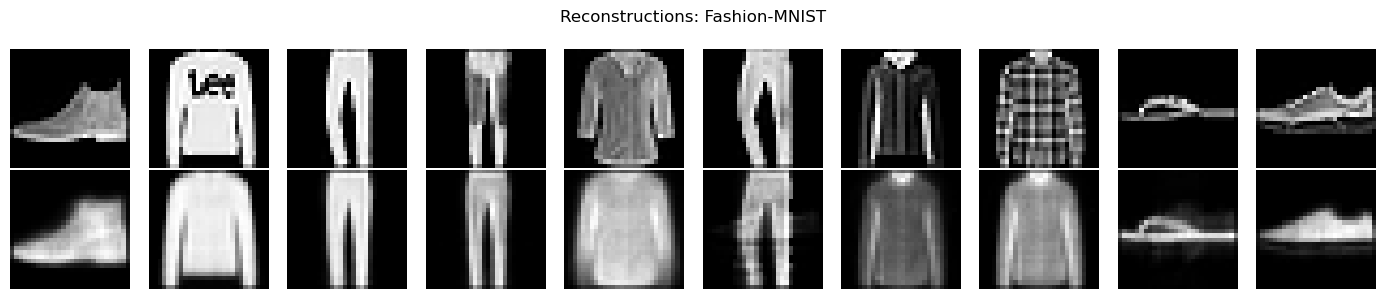

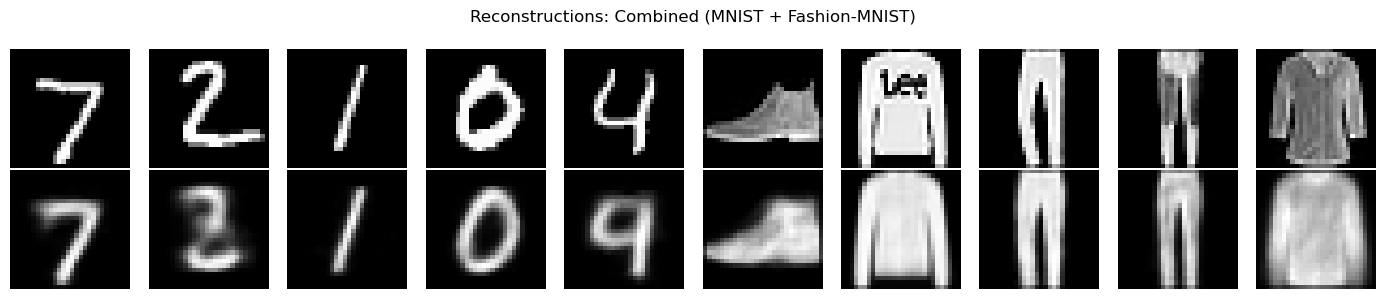

In [15]:
def show_reconstructions(model, test_loader, title, device, n=10):
    model.eval()
    model.to(device)

    images, _ = next(iter(test_loader))
    images    = images[:n].to(device)

    with torch.no_grad():
        reconstructed, _ = model(images)

    images        = images.cpu()
    reconstructed = reconstructed.cpu()

    fig, axes = plt.subplots(2, n, figsize=(14, 3))
    fig.suptitle(f'Reconstructions: {title}', fontsize=12)

    for i in range(n):
        axes[0, i].imshow(images[i].squeeze(),        cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Original',      fontsize=9)
    axes[1, 0].set_ylabel('Reconstructed', fontsize=9)
    plt.tight_layout()
    plt.show()


show_reconstructions(model_mnist,  mnist_test_loader,  'MNIST',         device)
show_reconstructions(model_fmnist, fmnist_test_loader, 'Fashion-MNIST', device)

# Build a 50/50 mixed batch for the combined reconstruction: 5 MNIST + 5 Fashion-MNIST
imgs_m, _ = next(iter(mnist_test_loader))
imgs_f, _ = next(iter(fmnist_test_loader))
mixed_imgs   = torch.cat([imgs_m[:5], imgs_f[:5]], dim=0)
mixed_loader = DataLoader(
    TensorDataset(mixed_imgs, torch.zeros(10, dtype=torch.long)),
    batch_size=10
)
show_reconstructions(model_combined, mixed_loader, 'Combined (MNIST + Fashion-MNIST)', device)

---
## Save Trained Models

Model weights are saved as state dictionaries. To reload:
```python
model = VanillaAutoencoder(latent_dim=2)
model.load_state_dict(torch.load('saved_models/autoencoder_mnist.pth'))
model.eval()
```

In [ ]:
save_dir = 'saved_models'
os.makedirs(save_dir, exist_ok=True)

torch.save(model_mnist.state_dict(),    os.path.join(save_dir, 'autoencoder_mnist.pth'))
torch.save(model_fmnist.state_dict(),   os.path.join(save_dir, 'autoencoder_fmnist.pth'))
torch.save(model_combined.state_dict(), os.path.join(save_dir, 'autoencoder_combined.pth'))

print(f'Models saved to ./{save_dir}/')
for fname in os.listdir(save_dir):
    fpath   = os.path.join(save_dir, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {fname}  ({size_kb:.1f} KB)')

Models saved to ./saved_models/
  autoencoder_combined.pth  (1837.0 KB)
  autoencoder_fmnist.pth  (1837.0 KB)
  autoencoder_mnist.pth  (1837.0 KB)


---
## Summary

| Model | Dataset | Latent Dim | Parameters |
|-------|---------|------------|------------|
| `model_mnist` | MNIST | 2 | ~270K |
| `model_fmnist` | Fashion-MNIST | 2 | ~270K |
| `model_combined` | MNIST + Fashion-MNIST | 2 | ~270K |

**Key takeaways:**
- Even with just 2 latent dimensions, the encoder learns to cluster similar images in the latent space.
- The image grid shows smooth morphing between styles as we walk through latent space.
- The combined model must compress two visual domains into the same 2D space, leading to more overlap between clusters and blurrier reconstructions compared to single-dataset models.
- Increasing `LATENT_DIM` (configured at the top) trades visualization interpretability for reconstruction sharpness.